In [1]:
## Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import the csv file
df = pd.read_csv('/content/drive/MyDrive/BRProject/Data/day.csv')

In [4]:
# Shape of the dataset
df.shape

(731, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
# Read the data
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
# Rename the columns
df.rename(columns={'instant':'rec_id',
                   'dteday':'datetime',
                   'yr':'year',
                   'mnth':'month',
                   'weathersit':'weather_condition',
                   'hum':'humidity',
                   'cnt':'total_count'},inplace=True)

In [8]:
df.head()

,rec_id,datetime,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [9]:
# Typecasting the datetime and numerical attributes to category

df['datetime'] = pd.to_datetime(df['datetime'])

df['season'] = df['season'].astype('category')
df['year'] = df['year'].astype('category')
df['month'] = df['month'].astype('category')
df['holiday'] = df['holiday'].astype('category')
df['workingday'] = df['workingday'].astype('category')
df['weather_condition'] = df['weather_condition'].astype('category')


In [10]:
df.describe()

,rec_id,datetime,weekday,temp,atemp,humidity,windspeed,casual,registered,total_count
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.997264,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,5.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,6.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,2.004787,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [11]:
# Missing values in dataset
df.isnull().sum()

,0
rec_id,0
datetime,0
season,0
year,0
month,0
holiday,0
weekday,0
workingday,0
weather_condition,0
temp,0


### Monthly distribution of counts

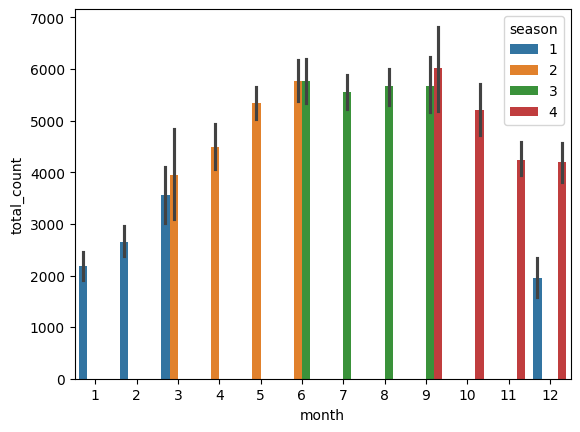

In [12]:
# Bar plot for seasonwise monthly distribution of counts
sns.barplot(x='month',y='total_count',data=df[['month','total_count','season']],hue='season')
plt.show()

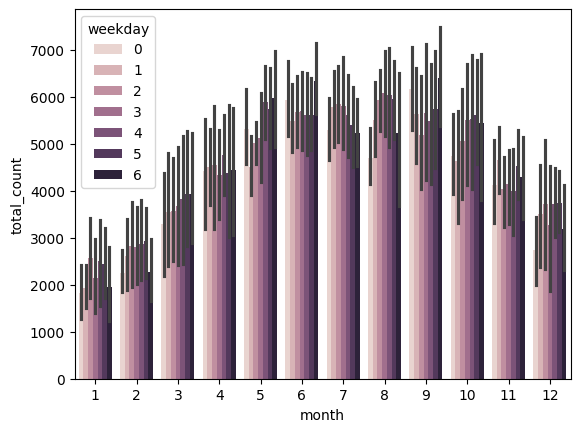

In [13]:
# Bar plot for weekday wise monthly distribution of counts
sns.barplot(x='month',y='total_count',data=df[['month','total_count','weekday']],hue='weekday')
plt.show()



From the above plots, we can observed that increasing the bike rental count in spring and summer season and then decreasing the bike rental count in fall and winter season. Here,

season 1-> spring
season 2 -> summer
season 3 -> fall
season 4 -> winter


### Yearly wise distribution of counts

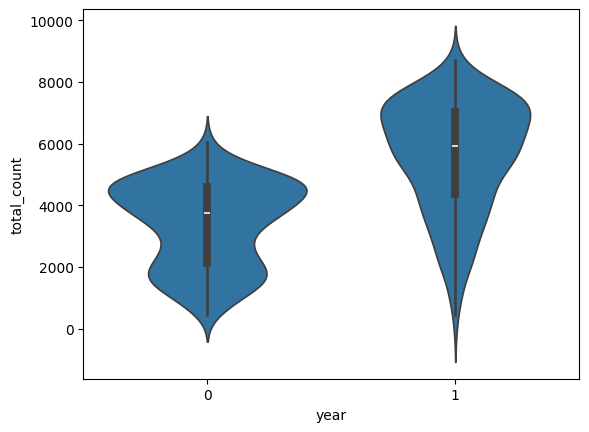

In [14]:
# Violin plot for yearly distribution of counts
sns.violinplot(x='year',y='total_count',data=df[['year','total_count']])
plt.show()



From the violin plot, we can observed that the bike rental count distribution is highest in year 2012 then in year 2011.

Here,
year 0-> 2011, year 1-> 2012


### Holiday wise distribution of counts

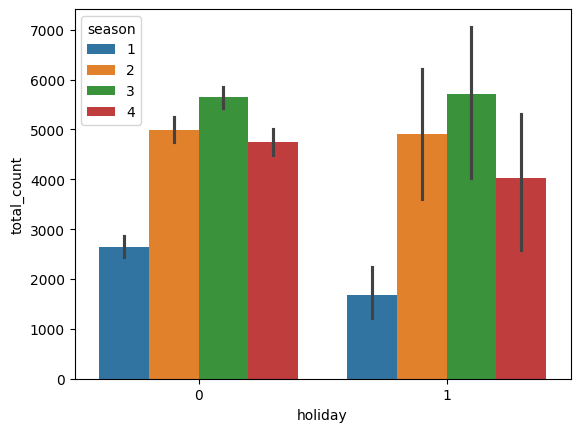

In [15]:
# Barplot for Holiday distribution of counts
sns.barplot(x='holiday',y='total_count',data=df[['holiday','total_count','season']],hue='season')
plt.show()



From the above bar plot, we can observed that during no holiday the bike rental counts is highest compared to during holiday for different seasons.

Here, 0->No holiday, 1-> holiday


### Workingday wise distribution of counts

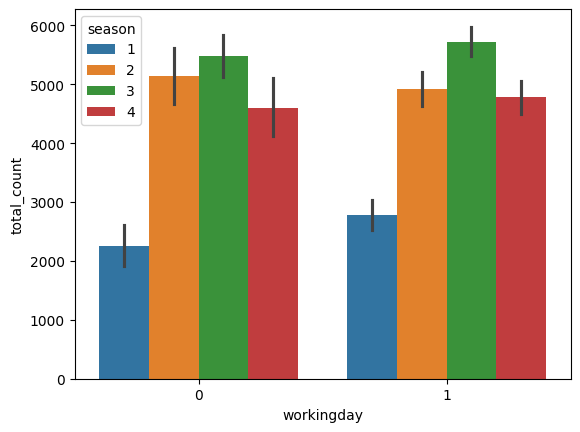

In [16]:
# Bar plot for workingday distribution of counts
sns.barplot(x='workingday',y='total_count',data=df[['workingday','total_count','season']],hue='season')
plt.show()



From the above bar plot, we can observed that during workingday the bike rental counts is quite highest compared to during no workingday for different seasons.

Here, 0-> No workingday, 1-> workingday




### Weather_condition distribution of counts


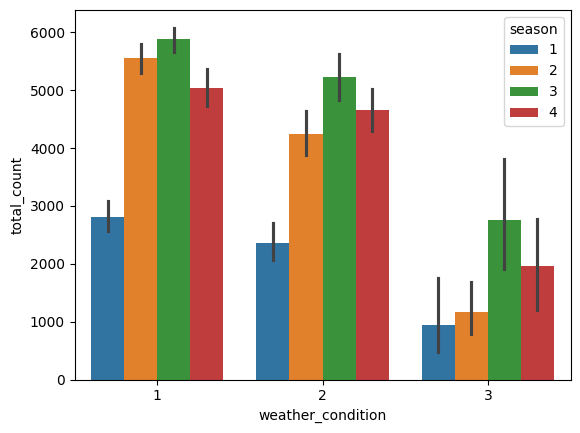

In [17]:
# Bar plot for weather_condition distribution of counts
sns.barplot(x='weather_condition',y='total_count',data=df[['weather_condition','total_count','season']],hue='season')
plt.show()



From the above bar plot, we can observed that during clear,partly cloudy weather the bike rental count is highest and the second highest is during mist cloudy weather and followed by third highest during light snow and light rain weather.




## Outlier analysis


###Total_Count_Outliers


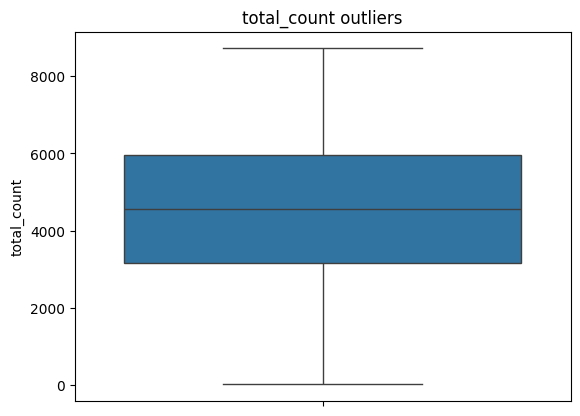

In [18]:
outliers = sns.boxplot(data=df['total_count'])
outliers.set_title('total_count outliers')
plt.show()


##Temp_windspeed_humidity_outliers

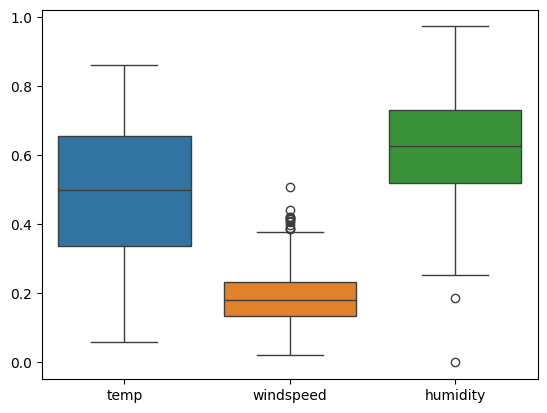

In [19]:
sns.boxplot(data=df[['temp','windspeed','humidity']])
plt.show()

From the box plot, we can observed that no outliers are present in normalized temp but few outliers are present in normalized windspeed and humidity variable.

In [20]:
df.head()

,rec_id,datetime,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Replace and impute the outliers**

In [21]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer

# Create dataframe for outliers
wind_hum = pd.DataFrame(df, columns=['windspeed', 'humidity'])

# Cnames for outliers
cnames = ['windspeed', 'humidity']

# Replace outliers with NaN
for i in cnames:
    q75, q25 = np.percentile(wind_hum.loc[:, i], [75, 25])  # 75% and 25% quantiles
    iqr = q75 - q25                                        # Interquartile range
    min_val = q25 - (iqr * 1.5)                            # Inner fence
    max_val = q75 + (iqr * 1.5)                            # Outer fence

    # Corrected → replace only the current column
    wind_hum.loc[wind_hum.loc[:, i] < min_val, i] = np.nan
    wind_hum.loc[wind_hum.loc[:, i] > max_val, i] = np.nan

# Apply KNN Imputer
imputer = KNNImputer(n_neighbors=3)
wind_hum_imputed = pd.DataFrame(
    imputer.fit_transform(wind_hum),
    columns=wind_hum.columns
)

print(wind_hum_imputed.head())


   windspeed  humidity
0   0.160446  0.805833
1   0.248539  0.696087
2   0.248309  0.437273
3   0.160296  0.590435
4   0.186900  0.436957


In [22]:
df['windspeed'] = df['windspeed'].replace(wind_hum_imputed['windspeed'])
df['humidity'] = df['humidity'].replace(wind_hum_imputed['humidity'])

In [23]:
df.head()

,rec_id,datetime,season,year,month,holiday,weekday,workingday,weather_condition,temp,atemp,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Normal Probability Plot**



Normal probability plot is a graphical technique to identify substantive departures from normality and also it tells about goodness of fit.


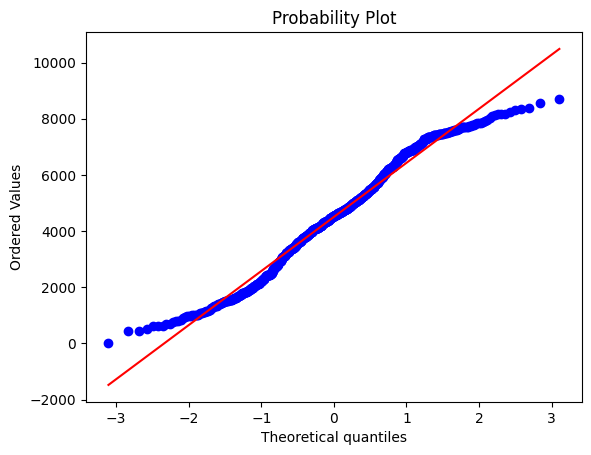

In [24]:
import scipy
from scipy import stats
#Normal plot
stats.probplot(df['total_count'], dist="norm", plot=plt)
plt.show()



The above probability plot, the some target variable data points are deviates from normality.



**Correlation matrix**



Correlation matrix is tells about linear relationship between attributes and help us to build better models.


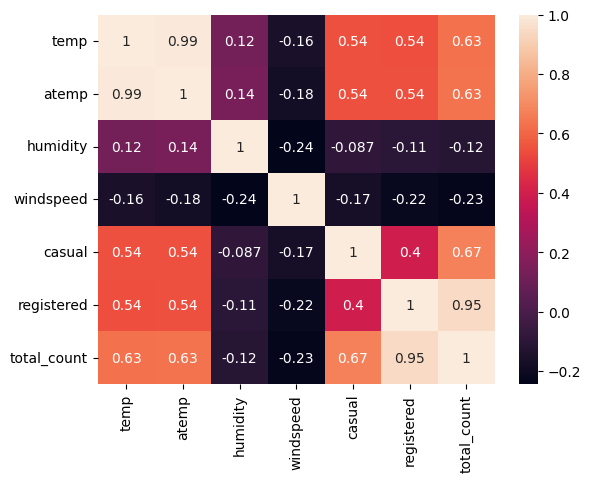

In [25]:
#Create the correlatiomn matrix

correMtr = df[["temp","atemp","humidity","windspeed","casual","registered","total_count"]].corr()
sns.heatmap(correMtr,annot=True)
plt.show()



From correlation plot, we can observed that some features are positively correlated or some are negatively correlated to each other. The temp and atemp are highly positively correlated to each other, it means that both are carrying same information.The total_count,casual and registered are highly positively correlated to each other. So, we are going to ignore atemp,casual and registered variable for further analysis.


**Modelling the dataset**

In [26]:
#load the required librariesz
from sklearn import preprocessing,metrics,linear_model
from sklearn.model_selection import cross_val_score,cross_val_predict,train_test_split



Split the dataset into train and test in the ratio of 70:30


In [31]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(['casual','registered','total_count'],axis=1),df['total_count'],test_size=0.3,random_state=42)

#Reset train index values
X_train.reset_index(inplace=True)
y_train=y_train.reset_index()

# Reset train index values
X_test.reset_index(inplace=True)
y_test=y_test.reset_index()

print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)
print(y_train.head())
print(y_test.head())

(511, 14) (220, 14) (511, 2) (220, 2)
   index  total_count
0    223         4905
1    684         5445
2    685         5698
3    163         5020
4    394         3624
   index  total_count
0    703         6606
1     33         1550
2    300         3747
3    456         6041
4    633         7538




Split the features into categorical and numerical features


In [32]:
#Create a new dataset for train attributes
train_attributes=X_train[['season','month','year','weekday','holiday','workingday','weather_condition','humidity','temp','windspeed']]
#Create a new dataset for test attributes
test_attributes=X_test[['season','month','year','weekday','holiday','workingday','humidity','temp','windspeed','weather_condition']]

In [33]:
#categorical attributes
cat_attributes=['season','holiday','workingday','weather_condition','year']
#numerical attributes
num_attributes=['temp','windspeed','humidity','month','weekday']



Decoding the training attributes


In [35]:
#To get dummy variables to encode the categorical features to numeric
train_encoded_attributes=pd.get_dummies(train_attributes,columns=cat_attributes,dtype=int)
print('Shape of transfomed dataframe:',train_encoded_attributes.shape)
train_encoded_attributes.head(5)

Shape of transfomed dataframe: (511, 18)


,month,weekday,humidity,temp,windspeed,season_1,season_2,season_3,season_4,holiday_0,holiday_1,workingday_0,workingday_1,weather_condition_1,weather_condition_2,weather_condition_3,year_0,year_1
0,8,5,0.415000,0.708333,0.125621,0,0,1,0,1,0,0,1,1,0,0,1,0
1,11,4,0.620417,0.321667,0.152987,0,0,0,1,1,0,0,1,0,1,0,0,1
2,11,5,0.524583,0.345000,0.171025,0,0,0,1,1,0,0,1,1,0,0,0,1
3,6,1,0.494583,0.635000,0.305350,0,1,0,0,1,0,0,1,1,0,0,1,0
4,1,1,0.400833,0.269167,0.215792,1,0,0,0,1,0,0,1,1,0,0,0,1


Training dataset

In [36]:
#Training dataset for modelling
X_train=train_encoded_attributes
y_train=y_train.total_count.values



Linear Regression Model


In [37]:
#training model
lr_model=linear_model.LinearRegression()
lr_model

LinearRegression()



fit the training mode

In [38]:
#fit the trained model
lr_model.fit(X_train,y_train)

LinearRegression()



Accuracy of model


In [39]:
#Accuracy of the model
lr=lr_model.score(X_train,y_train)
print('Accuracy of the model :',lr)
print('Model coefficients :',lr_model.coef_)
print('Model intercept value :',lr_model.intercept_)

Accuracy of the model : 0.8165025087335218
Model coefficients : [  -25.40093273    69.00041734 -1021.83801516  5265.83269167
 -2556.15204574  -949.34444399   229.82675107   -79.72789531
   799.24558823   228.48467064  -228.48467064   -78.95445063
    78.95445063   761.85445399   252.23446226 -1014.08891625
  -989.30080604   989.30080604]
Model intercept value : 2195.3105623488336


Cross validation prediction

In [40]:
#Cross validation prediction
predict=cross_val_predict(lr_model,X_train,y_train,cv=3)
predict

array([ 5248.7578435 ,  5038.5615668 ,  5806.79339316,  4353.94868702,
        3738.02165465,  6781.13199665,  6258.53686563,  3802.32154757,
        4679.69060739,  3413.26938345,  5382.26926795,  3103.26413427,
        4340.14502978,  5792.02135524,  4357.90482085,  6307.47067538,
        4382.53420011,  3356.51602988,   722.55880035,   542.99629923,
        7419.07107033,  3747.2639444 ,  5282.38323084,  5494.01243603,
        6941.05375802,  7322.95928003,  3629.5886932 ,  3571.12912785,
         985.45343201,  4884.05952005,  1644.73801661,  1708.88196943,
        1689.90104258,  1295.63879625,  4891.47726849,  5507.81236621,
        6015.17425095,  4180.63057735,  5075.38404498,  5941.56769703,
        6400.40498745,  4215.81855312,  5962.38814912,  6052.71452714,
        3345.73314148,  4096.72004817,  1465.44713372,  3603.17274178,
        4587.89942466,  6650.65699064,  1719.93360965,  6128.15135134,
        6439.33525805,  3277.84008997,  4592.0786174 ,  3194.61235   ,
      

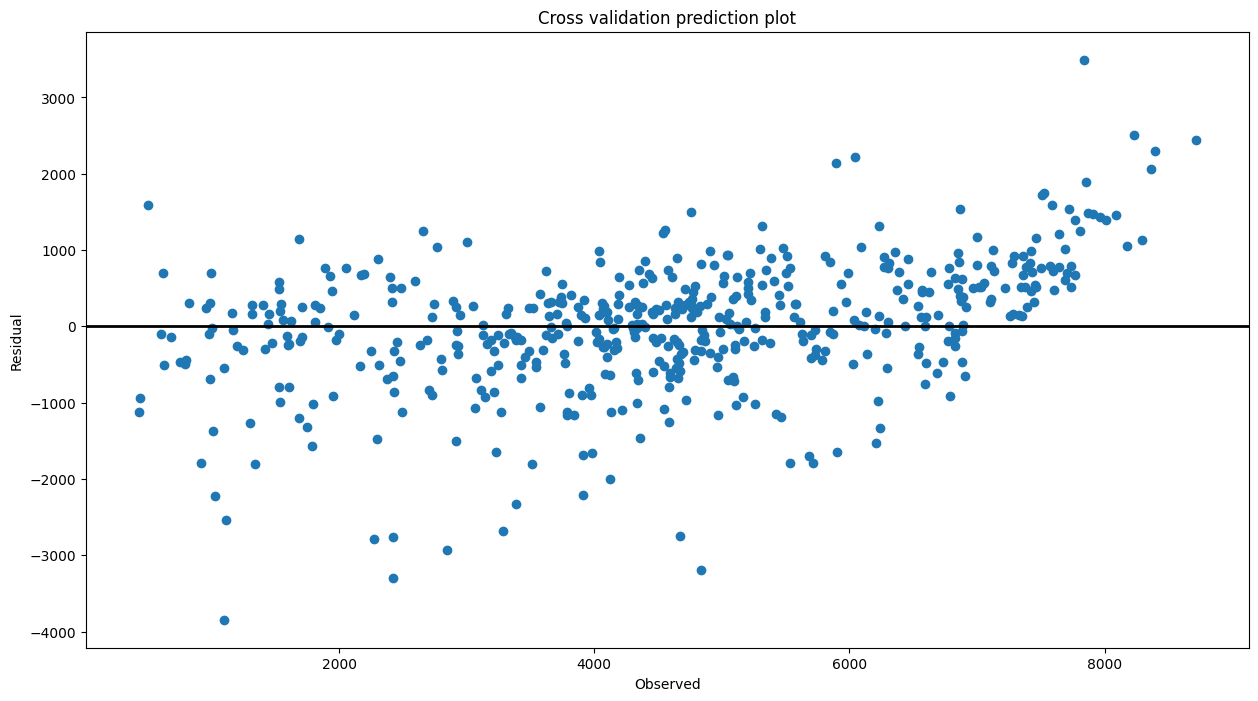

In [43]:
fig,ax=plt.subplots(figsize=(15,8))
ax.scatter(y_train,y_train-predict)
ax.axhline(lw=2,color='black')
ax.set_title('Cross validation prediction plot')
ax.set_xlabel('Observed')
ax.set_ylabel('Residual')
plt.show()



Cross validation prediction plot tells about finite variance between actual target value and predicted target value. In this plot, some data points are have same finite variance between them and for some are not have it.



**Model evalution metrics**

**R-squared and mean squared error score**

In [45]:
#R-squared scores
r2_scores = cross_val_score(lr_model, X_train, y_train, cv=3)
print('R-squared scores :',np.average(r2_scores))

R-squared scores : 0.7995611885231045


The R-squared or coefficient of determination is 0.80 on average for 3-fold cross validation , it means that predictor is only able to predict 80% of the variance in the target variable which is contributed by independent variables.

**Decoding the test attributes**

In [47]:
#To get dummy variables to encode the categorical features to numeric
test_encoded_attributes=pd.get_dummies(test_attributes,columns=cat_attributes,dtype=int)
print('Shape of transformed dataframe :',test_encoded_attributes.shape)
test_encoded_attributes.head(5)

Shape of transformed dataframe : (220, 18)


,month,weekday,humidity,temp,windspeed,season_1,season_2,season_3,season_4,holiday_0,holiday_1,workingday_0,workingday_1,weather_condition_1,weather_condition_2,weather_condition_3,year_0,year_1
0,12,2,0.733750,0.475833,0.174129,0,0,0,1,1,0,0,1,1,0,0,0,1
1,2,4,0.437826,0.186957,0.277752,1,0,0,0,1,0,0,1,1,0,0,1,0
2,10,5,0.585833,0.330833,0.229479,0,0,0,1,1,0,0,1,0,1,0,1,0
3,4,0,0.676250,0.425833,0.172267,0,1,0,0,1,0,1,0,0,1,0,0,1
4,9,2,0.570000,0.550000,0.236321,0,0,0,1,1,0,0,1,1,0,0,0,1


**Model performance on test dataset**

In [48]:
#Test dataset for prediction
X_test=test_encoded_attributes
y_test=y_test.total_count.values



**Predict the model**

In [49]:
#predict the model
lr_pred=lr_model.predict(X_test)
lr_pred

array([6197.12329782, 1378.27938018, 3212.82326914, 4825.6058012 ,
       6672.2308762 , 6942.2039349 ,  693.99373527, 1929.80808599,
       6981.48110092, 6844.67173725, 2798.54559266, 2121.8457389 ,
       4465.68268321, 5486.74428544, 2189.59008463, 1827.67433934,
       2173.48158771, 7469.58027211, 5500.15015098, 2608.49336522,
       6933.20124884, 7837.10306473, 5532.48547104, 1261.13929139,
       1245.46616862, 4479.83361908, 2496.61989036, 6733.37234742,
       3854.86011528, 5802.97615092, 3103.90712661, 4252.34563973,
       6358.26561572, 6798.3144729 , 5790.26253638, 5402.54802544,
       6692.75313381, 5848.44121572, 3180.98457936,  805.80292438,
       4497.72178336, 3746.59014984, 6903.03554988, 4077.94155535,
       6907.0442079 , 1687.7942605 , 4801.49297945, 4723.9530173 ,
       6369.39948476, 4579.39869385, 3105.76669461, 2833.81705416,
       1829.36260472, 5601.65932265, 4625.78263028, 4089.39223053,
       4695.03945324, 3038.41700558, 4351.67190815, 6630.97204

**Model evaluation metrics**

**Root mean square error and mean absolute error scores**

In [50]:
import math
#Root mean square error
rmse=math.sqrt(metrics.mean_squared_error(y_test,lr_pred))
#Mean absolute error
mae=metrics.mean_absolute_error(y_test,lr_pred)
print('Root mean square error :',rmse)
print('Mean absolute error :',mae)

Root mean square error : 783.0616972625058
Mean absolute error : 594.7368430236425


**Residual plot**

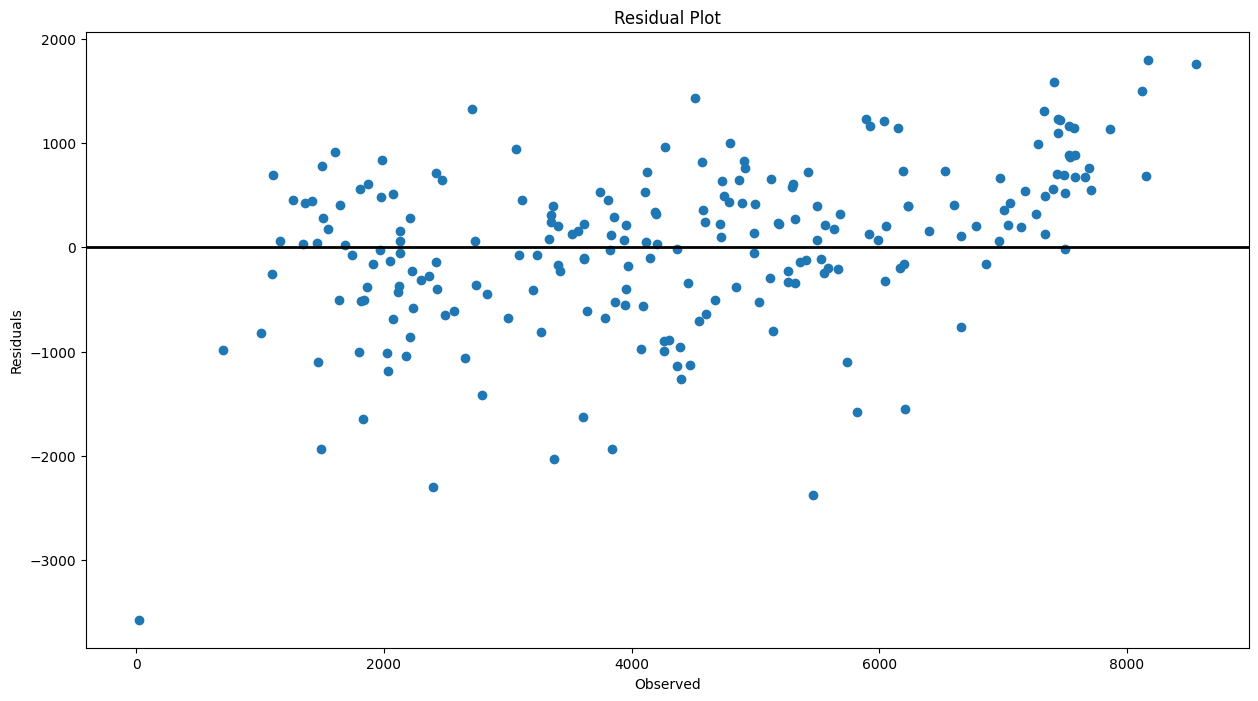

In [51]:
#Residual plot
fig, ax = plt.subplots(figsize=(15,8))
ax.scatter(y_test, y_test-lr_pred)
ax.axhline(lw=2,color='black')
ax.set_xlabel('Observed')
ax.set_ylabel('Residuals')
ax.title.set_text("Residual Plot")
plt.show()



Residual plot tells about finite variance between actual target value and predicted target value.In this plot,very less data points are have same finite variance between them and for most are not have it.


**Decision tree regressor**

In [52]:
#training the model
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(min_samples_split=2,max_leaf_nodes=10)

**Fit the model**

In [53]:
#Fit the trained model
dtr.fit(X_train,y_train)

DecisionTreeRegressor(max_leaf_nodes=10)

**Decision tree regression accuracy score**

In [55]:
#Accuracy score of the model
dtr_score=dtr.score(X_train,y_train)
print('Accuracy of model :',dtr_score)

Accuracy of model : 0.8082151777539757




Cross validation prediction


In [57]:
predict=cross_val_predict(dtr,X_train,y_train,cv=3)
predict

array([4513.38554217, 4592.56521739, 4592.56521739, 4513.38554217,
       2558.6       , 5388.47058824, 6824.96969697, 4592.56521739,
       4592.56521739, 3603.92857143, 6824.96969697, 3194.22222222,
       4513.38554217, 6824.96969697, 4513.38554217, 6824.96969697,
       3603.92857143, 1636.81818182, 1636.81818182, 1636.81818182,
       6824.96969697, 2558.6       , 4592.56521739, 1027.        ,
       6824.96969697, 6824.96969697, 2558.6       , 4592.56521739,
       1636.81818182, 4513.38554217, 1636.81818182, 1636.81818182,
       1636.81818182, 1636.81818182, 4513.38554217, 5388.47058824,
       6824.96969697, 4592.56521739, 4513.38554217, 6824.96969697,
       6824.96969697, 4513.38554217, 6824.96969697, 6824.96969697,
       4513.38554217, 3194.22222222, 1636.81818182, 4592.56521739,
       4513.38554217, 6824.96969697, 3194.22222222, 6824.96969697,
       6824.96969697, 3603.92857143, 4513.38554217, 1027.        ,
       1636.81818182, 4513.38554217, 1636.81818182, 4513.38554



Cross validation prediction plot


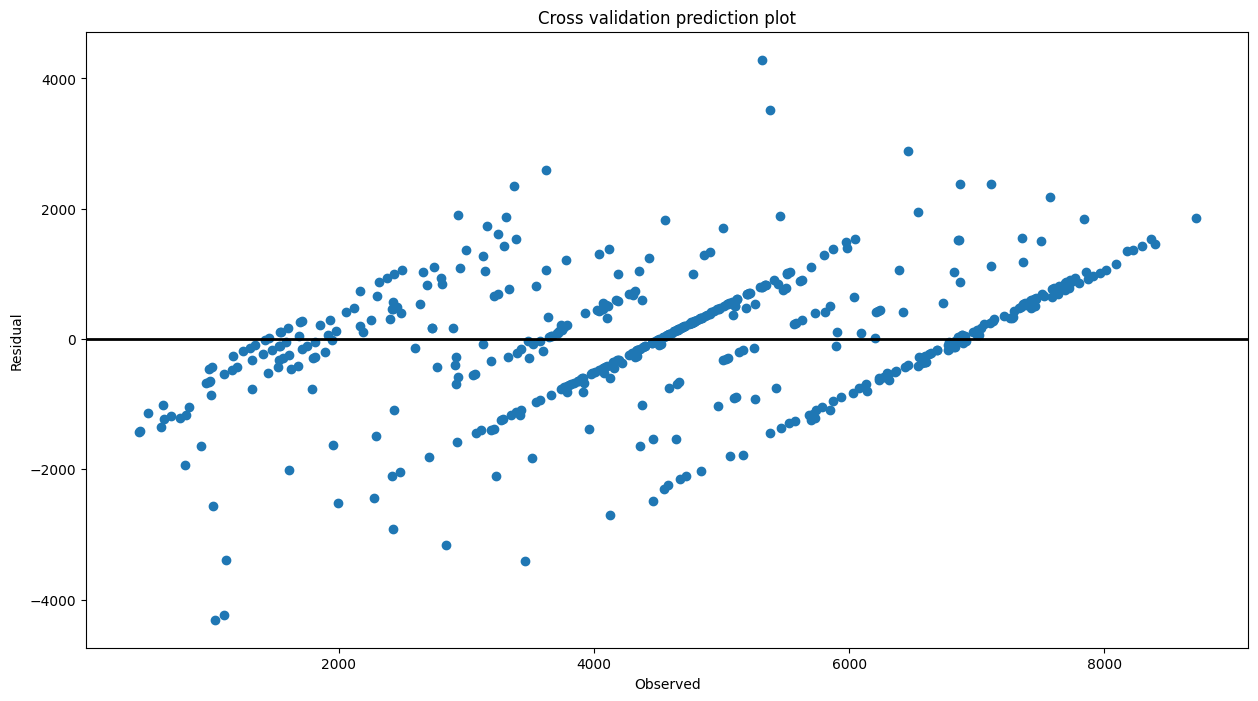

In [58]:
# Cross validation prediction plot
fig,ax=plt.subplots(figsize=(15,8))
ax.scatter(y_train,y_train-predict)
ax.axhline(lw=2,color='black')
ax.set_title('Cross validation prediction plot')
ax.set_xlabel('Observed')
ax.set_ylabel('Residual')
plt.show()



Cross validation prediction plot tells about finite variance between actual target value and predicted target value. In this plot,some data points are have same finite variance between them and for some are not have it.




**Model evalution metrics**




**R-squared and mean squared error scores**


In [59]:
#R-squared scores
r2_scores = cross_val_score(dtr, X_train, y_train, cv=3)
print('R-squared scores :',np.average(r2_scores))

R-squared scores : 0.7294133148789058




The R-squared or coefficient of determination is 0.72 on average for 3-fold cross validation ,it means that predictor is only able to predict 72% of the variance in the target variable which is contributed by independent variables.


**Model performance on test dataset**

In [60]:
#predict the model
dtr_pred=dtr.predict(X_test)
dtr_pred

array([6777.95      , 1848.95454545, 3612.69230769, 5277.09375   ,
       6777.95      , 6777.95      , 1848.95454545, 1992.25      ,
       6777.95      , 6777.95      , 1848.95454545, 1992.25      ,
       4465.04444444, 5277.09375   , 1992.25      , 1992.25      ,
       1992.25      , 6777.95      , 4465.04444444, 1848.95454545,
       6777.95      , 6777.95      , 5277.09375   , 1848.95454545,
       1992.25      , 4465.04444444, 1992.25      , 6777.95      ,
       1848.95454545, 5277.09375   , 1848.95454545, 4465.04444444,
       6777.95      , 6777.95      , 6777.95      , 5484.22727273,
       6777.95      , 6777.95      , 4465.04444444, 1848.95454545,
       4465.04444444, 1848.95454545, 6777.95      , 4465.04444444,
       6777.95      , 3612.69230769, 4465.04444444, 6777.95      ,
       6777.95      , 5484.22727273, 4465.04444444, 1848.95454545,
       1992.25      , 4465.04444444, 4465.04444444, 4465.04444444,
       3170.41666667, 4465.04444444, 4465.04444444, 6777.95   

**Root mean squared error and mean absolute error**

In [61]:
#Root mean square error
rmse=math.sqrt(metrics.mean_squared_error(y_test,dtr_pred))
#Mean absolute error
mae=metrics.mean_absolute_error(y_test,dtr_pred)
print('Root mean square error :',rmse)
print('Mean absolute error :',mae)

Root mean square error : 925.7976022448886
Mean absolute error : 667.8169018859927


**Residual plot**

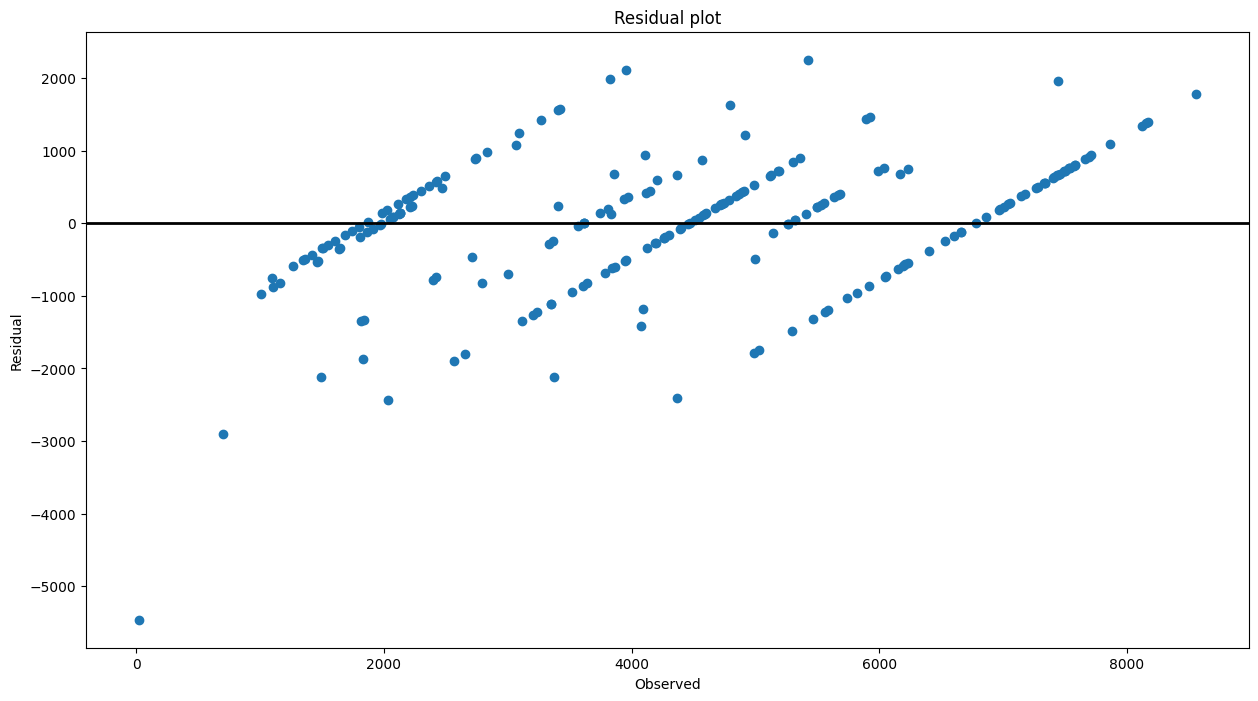

In [62]:
#Residual scatter plot
residuals = y_test-dtr_pred
fig, ax = plt.subplots(figsize=(15,8))
ax.scatter(y_test, residuals)
ax.axhline(lw=2,color='black')
ax.set_xlabel('Observed')
ax.set_ylabel('Residual')
ax.set_title('Residual plot')
plt.show()



Residual plot tells about finite variance between actual target value and predicted target value. In this plot, some data points are have same finite variance between them and for some are not have it.


**RandomForest**

In [63]:
#Training the model
from sklearn.ensemble import RandomForestRegressor
X_train=train_encoded_attributes
rf=RandomForestRegressor(n_estimators=200)

**Fit the model**

In [64]:
#Fit the trained model
rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200)

**Random forest accuracy score**

In [65]:
#accuracy of the model
rf_score =rf.score(X_train,y_train)
print('Accuracy of the model :',rf_score)

Accuracy of the model : 0.9805943124000163


**Cross validation prediction**

In [67]:
#Cross validation prediction
predict=cross_val_predict(rf,X_train,y_train,cv=3)
predict

array([4947.705, 4834.855, 5316.775, 4801.24 , 3059.205, 5771.175,
       6629.66 , 3743.025, 4242.06 , 3597.185, 5949.295, 3389.405,
       4276.14 , 6979.335, 4923.   , 6588.65 , 4024.595, 2645.23 ,
       1185.31 , 1358.165, 6250.42 , 3402.44 , 4673.64 , 4488.885,
       7170.08 , 6256.595, 3194.145, 4231.645, 1423.13 , 4953.71 ,
       1031.69 , 1879.07 , 1463.44 , 1908.99 , 4711.615, 5048.165,
       6844.565, 4019.005, 4340.06 , 6108.65 , 6614.815, 4330.745,
       7203.155, 6454.83 , 4455.08 , 3396.48 , 1282.59 , 3926.57 ,
       4704.805, 6510.755, 2819.025, 6488.255, 6549.025, 3354.705,
       4932.08 , 3173.54 , 1399.31 , 4146.37 , 1086.77 , 4653.845,
       5441.5  , 4163.28 , 3666.485, 5640.19 , 4456.34 , 7007.79 ,
       4606.275, 3178.17 , 3768.91 , 4220.22 , 3651.155, 4445.725,
       7180.735, 3713.405, 5013.345, 2377.045, 2533.45 , 4572.43 ,
       2040.05 , 4344.685, 4340.415, 4691.95 , 4176.555, 2073.135,
       7628.78 , 4339.365, 4625.925, 7235.51 , 4601.29 , 4214.

**Cross validation prediction plot**

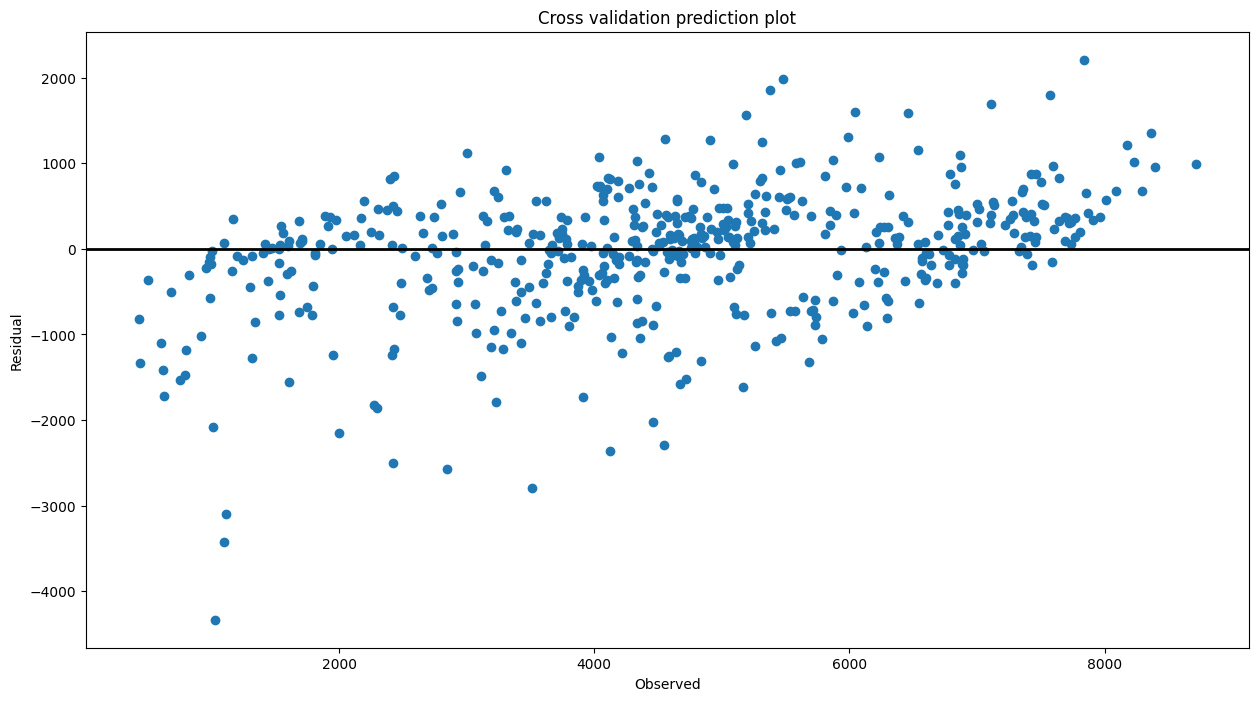

In [68]:
#Cross validation prediction plot
fig,ax=plt.subplots(figsize=(15,8))
ax.scatter(y_train,y_train-predict)
ax.axhline(lw=2,color='black')
ax.set_title('Cross validation prediction plot')
ax.set_xlabel('Observed')
ax.set_ylabel('Residual')
plt.show()

Cross validation prediction plot tells about finite variance between actual target value and predicted target value. In this plot,some data points are have same finite variance between them and for some are not have it.

**R-squared and mean squared error scores**

In [69]:
#R-squared scores
r2_scores = cross_val_score(rf, X_train, y_train, cv=3)
print('R-squared scores :',np.average(r2_scores))

R-squared scores : 0.845295468265327


The R-squared or coefficient of determination is 0.85 on average for 3-fold cross validation , it means that predictor is only able to predict 85% of the variance in the target variable which is contributed by independent variables.

**Model performance on test dataset**

In [70]:
#predict the model
X_test=test_encoded_attributes
rf_pred=rf.predict(X_test)
rf_pred

array([6523.23 , 1519.01 , 3371.74 , 5246.815, 7476.675, 7274.84 ,
       1478.55 , 2235.925, 7216.925, 6486.405, 2104.265, 2885.98 ,
       4988.915, 4943.125, 2076.005, 2100.54 , 2247.145, 7840.015,
       5038.57 , 2463.44 , 7437.35 , 6086.75 , 5931.295, 1757.705,
       1747.19 , 4710.545, 1886.83 , 7234.875, 3205.495, 5719.885,
       3020.065, 4044.555, 6501.68 , 7281.875, 6110.515, 5399.195,
       7150.915, 6211.23 , 3221.495,  931.19 , 3783.355, 3284.85 ,
       7277.7  , 4525.775, 6910.06 , 2330.875, 4323.735, 5565.115,
       6584.64 , 4359.155, 4217.06 , 2934.775, 2310.77 , 4311.43 ,
       4650.695, 4196.255, 3723.63 , 3657.775, 4280.64 , 6633.66 ,
       6178.74 , 6816.105, 1977.475, 7321.25 , 6502.045, 6385.54 ,
       5918.41 , 4320.74 , 1896.625, 7364.75 , 3709.085, 2092.22 ,
       3253.695, 3873.94 , 4232.87 , 3830.405, 4632.475, 4487.38 ,
       1339.04 , 4311.875, 2406.485, 1980.85 , 5029.86 , 4391.085,
       3665.89 , 3405.31 , 4265.095, 3760.66 , 3427.705, 3350.

**Root mean squared error and mean absolute error**

In [72]:
#Root mean square error
rmse = math.sqrt(metrics.mean_squared_error(y_test,rf_pred))
print('Root mean square error :',rmse)
#Mean absolute error
mae=metrics.mean_absolute_error(y_test,rf_pred)
print('Mean absolute error :',mae)

Root mean square error : 643.8490258474102
Mean absolute error : 425.58375


**Residual plot**

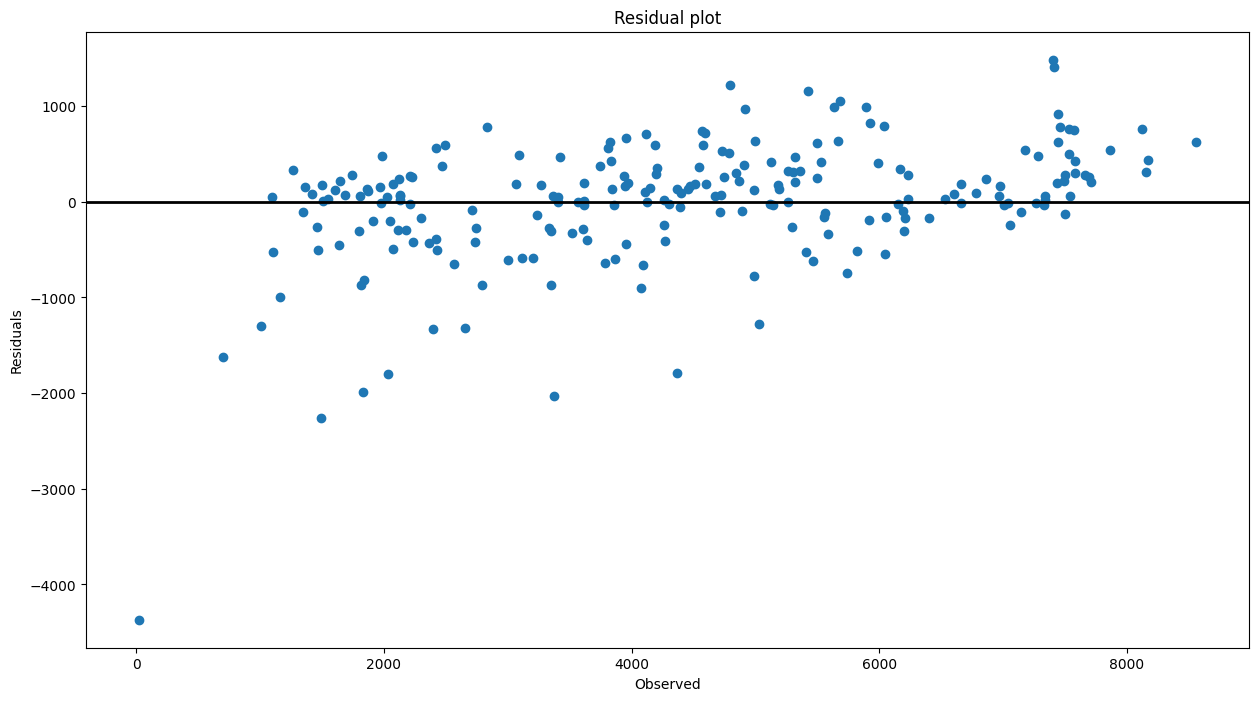

In [73]:
#Residual scatter plot
fig, ax = plt.subplots(figsize=(15,8))
residuals=y_test-rf_pred
ax.scatter(y_test, residuals)
ax.axhline(lw=2,color='black')
ax.set_xlabel('Observed')
ax.set_ylabel('Residuals')
ax.set_title('Residual plot')
plt.show()



Cross validation prediction plot tells about finite variance between actual target value and predicted target value.In this plot,some data points are have same finite variance between them and for some are not have it.


**Final model for predicting the bike rental count on daily basis**



When we compare the root mean squared error and mean absolute error of all 3 models, the random forest model has less root mean squared error and mean absolute error. So, finally random forest model is bset for predicting the bike rental count on daily basis.


In [75]:
Bike_df1=pd.DataFrame(y_test,columns=['y_test'])
Bike_df2=pd.DataFrame(rf_pred,columns=['rf_pred'])
Bike_predictions=pd.merge(Bike_df1,Bike_df2,left_index=True,right_index=True)
Bike_predictions

,y_test,rf_pred
0,6606,6523.230
1,1550,1519.010
2,3747,3371.740
3,6041,5246.815
4,7538,7476.675
...,...,...
215,2659,3980.970
216,7338,7283.000
217,6978,6817.025
218,4795,3573.890
